In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine

Matplotlib is building the font cache; this may take a moment.


In [4]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    BASE_DIR = current_path.parent
else:
    BASE_DIR = current_path

DATABASE_PATH = BASE_DIR / "database" / "vendor_iq.db"

engine = create_engine(f"sqlite:///{DATABASE_PATH.as_posix()}", echo=False)

print("Connected to:", DATABASE_PATH)

Connected to: d:\VendorIQ\database\vendor_iq.db


In [5]:
df = pd.read_sql_query("""
SELECT *
FROM vendor_performance_summary;
""", engine)

df.head()

,VendorNumber,VendorName,Brand,Description,total_purchase_quantity,total_purchase_dollars,avg_purchase_price,total_sales_quantity,total_sales_dollars,avg_sales_price,gross_profit,profit_margin_percent,unsold_quantity,sales_to_purchase_qty_ratio,sales_to_purchase_value_ratio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,8,190.88,23.86,18,665.82,36.99,474.94,71.33,-10,2.25,3.49
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,320,5440.00,17.00,24,599.76,24.99,-4840.24,-807.03,296,0.07,0.11
2,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,39,446.16,11.44,47,704.53,14.99,258.37,36.67,-8,1.21,1.58
3,60,ADAMBA IMPORTS INTL INC,3979,Vesica Potato Vodka,4687,76257.49,16.27,3931,66871.69,17.02,-9385.80,-14.04,756,0.84,0.88
4,105,ALTAMAR BRANDS LLC,2529,Right Gin,12,279.00,23.25,12,359.88,29.99,80.88,22.47,0,1.00,1.29


In [6]:
df.describe()

,VendorNumber,Brand,total_purchase_quantity,total_purchase_dollars,avg_purchase_price,total_sales_quantity,total_sales_dollars,avg_sales_price,gross_profit,profit_margin_percent,unsold_quantity,sales_to_purchase_qty_ratio,sales_to_purchase_value_ratio
count,10515.000000,10515.000000,10515.000000,1.051500e+04,10515.000000,10515.000000,1.051500e+04,10515.000000,1.051500e+04,10515.000000,10515.000000,10515.000000,10514.000000
mean,10599.401712,17973.837280,3192.739990,3.058665e+04,23.407141,3129.450404,4.295943e+04,33.835658,1.237279e+04,-15.874242,63.289586,1.735652,2.546770
std,18660.734977,12689.676059,11180.812291,1.240423e+05,92.165951,11037.284900,1.689706e+05,126.327293,4.658193e+04,447.270014,590.467612,6.066814,8.524071
min,2.000000,58.000000,1.000000,0.000000e+00,0.000000,1.000000,1.980000e+00,0.490000,-5.200278e+04,-23730.640000,-13304.000000,0.000000,0.000000
25%,3924.000000,5713.500000,36.000000,4.781700e+02,6.840000,36.000000,8.098200e+02,10.490000,6.699000e+01,15.360000,-13.000000,0.830000,1.180000
50%,7153.000000,18642.000000,281.000000,3.835150e+03,10.450000,280.000000,5.599720e+03,15.530000,1.497960e+03,30.780000,10.000000,0.980000,1.440000
75%,9552.000000,25465.500000,2028.500000,2.127954e+04,19.370000,1985.000000,2.952940e+04,27.990000,8.974235e+03,40.210000,67.000000,1.040000,1.670000
max,201359.000000,90631.000000,337660.000000,3.811252e+06,4264.700000,334939.000000,5.101920e+06,5799.990000,1.290668e+06,100.000000,13121.000000,274.500000,352.930000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10515 entries, 0 to 10514
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   VendorNumber                   10515 non-null  int64  
 1   VendorName                     10515 non-null  str    
 2   Brand                          10515 non-null  int64  
 3   Description                    10515 non-null  str    
 4   total_purchase_quantity        10515 non-null  int64  
 5   total_purchase_dollars         10515 non-null  float64
 6   avg_purchase_price             10515 non-null  float64
 7   total_sales_quantity           10515 non-null  int64  
 8   total_sales_dollars            10515 non-null  float64
 9   avg_sales_price                10515 non-null  float64
 10  gross_profit                   10515 non-null  float64
 11  profit_margin_percent          10515 non-null  float64
 12  unsold_quantity                10515 non-null  int64  
 1

In [8]:
df.isnull().sum()

VendorNumber                     0
VendorName                       0
Brand                            0
Description                      0
total_purchase_quantity          0
total_purchase_dollars           0
avg_purchase_price               0
total_sales_quantity             0
total_sales_dollars              0
avg_sales_price                  0
gross_profit                     0
profit_margin_percent            0
unsold_quantity                  0
sales_to_purchase_qty_ratio      0
sales_to_purchase_value_ratio    1
dtype: int64

In [9]:
df[df["sales_to_purchase_value_ratio"].isnull()]

,VendorNumber,VendorName,Brand,Description,total_purchase_quantity,total_purchase_dollars,avg_purchase_price,total_sales_quantity,total_sales_dollars,avg_sales_price,gross_profit,profit_margin_percent,unsold_quantity,sales_to_purchase_qty_ratio,sales_to_purchase_value_ratio
1944,2561,EDRINGTON AMERICAS,2166,The Macallan Double Cask 12,2015,0.0,0.0,1732,98245.68,56.99,98245.68,100.0,283,0.86,NaN


In [10]:
df["sales_to_purchase_value_ratio"] = df["sales_to_purchase_value_ratio"].fillna(0)

In [11]:
top_vendors_sales = (
    df.groupby("VendorName", as_index=False)
      .agg(
          total_sales_dollars=("total_sales_dollars", "sum"),
          total_sales_quantity=("total_sales_quantity", "sum"),
          gross_profit=("gross_profit", "sum")
      )
      .sort_values("total_sales_dollars", ascending=False)
      .head(10)
)

top_vendors_sales

,VendorName,total_sales_dollars,total_sales_quantity,gross_profit
27,DIAGEO NORTH AMERICA INC,68739834.97,5422335,17780047.56
61,MARTIGNETTI COMPANIES,40905207.45,2575633,13126986.83
73,PERNOD RICARD USA,32279544.17,1613338,8155452.61
49,JIM BEAM BRANDS COMPANY,31898621.16,2629964,7695470.11
7,BACARDI USA INC,25005365.79,1457011,7381036.77
22,CONSTELLATION BRANDS INC,24467134.23,2301458,8897424.94
32,E & J GALLO WINERY,18553774.66,1808718,6267615.25
13,BROWN-FORMAN CORP,18476611.60,983740,4947178.52
113,ULTRA BEVERAGE COMPANY LLP,17802646.10,1042270,4702674.50
57,M S WALKER INC,15436066.26,1342230,4557986.36


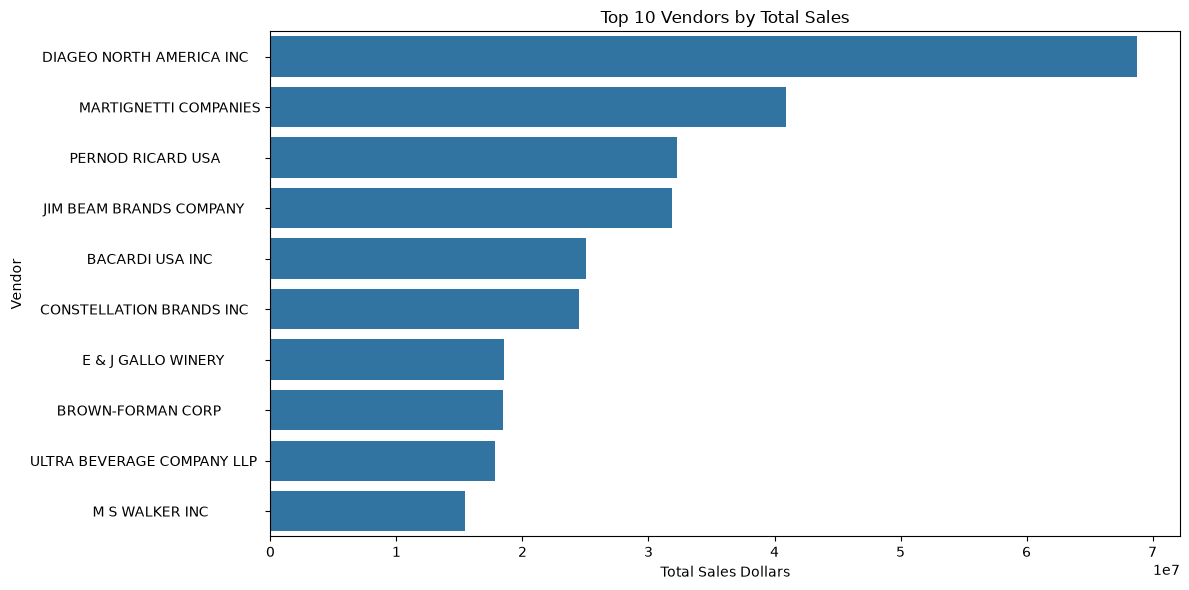

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_vendors_sales,
    x="total_sales_dollars",
    y="VendorName"
)

plt.title("Top 10 Vendors by Total Sales")
plt.xlabel("Total Sales Dollars")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

In [13]:
top_vendors_profit = (
    df.groupby("VendorName", as_index=False)
      .agg(
          gross_profit=("gross_profit", "sum"),
          total_sales_dollars=("total_sales_dollars", "sum"),
          total_purchase_dollars=("total_purchase_dollars", "sum")
      )
      .sort_values("gross_profit", ascending=False)
      .head(10)
)

top_vendors_profit

,VendorName,gross_profit,total_sales_dollars,total_purchase_dollars
27,DIAGEO NORTH AMERICA INC,17780047.56,68739834.97,50959787.41
61,MARTIGNETTI COMPANIES,13126986.83,40905207.45,27778220.62
22,CONSTELLATION BRANDS INC,8897424.94,24467134.23,15569709.29
73,PERNOD RICARD USA,8155452.61,32279544.17,24124091.56
49,JIM BEAM BRANDS COMPANY,7695470.11,31898621.16,24203151.05
7,BACARDI USA INC,7381036.77,25005365.79,17624329.02
32,E & J GALLO WINERY,6267615.25,18553774.66,12286159.41
13,BROWN-FORMAN CORP,4947178.52,18476611.60,13529433.08
113,ULTRA BEVERAGE COMPANY LLP,4702674.50,17802646.10,13099971.60
57,M S WALKER INC,4557986.36,15436066.26,10878079.90


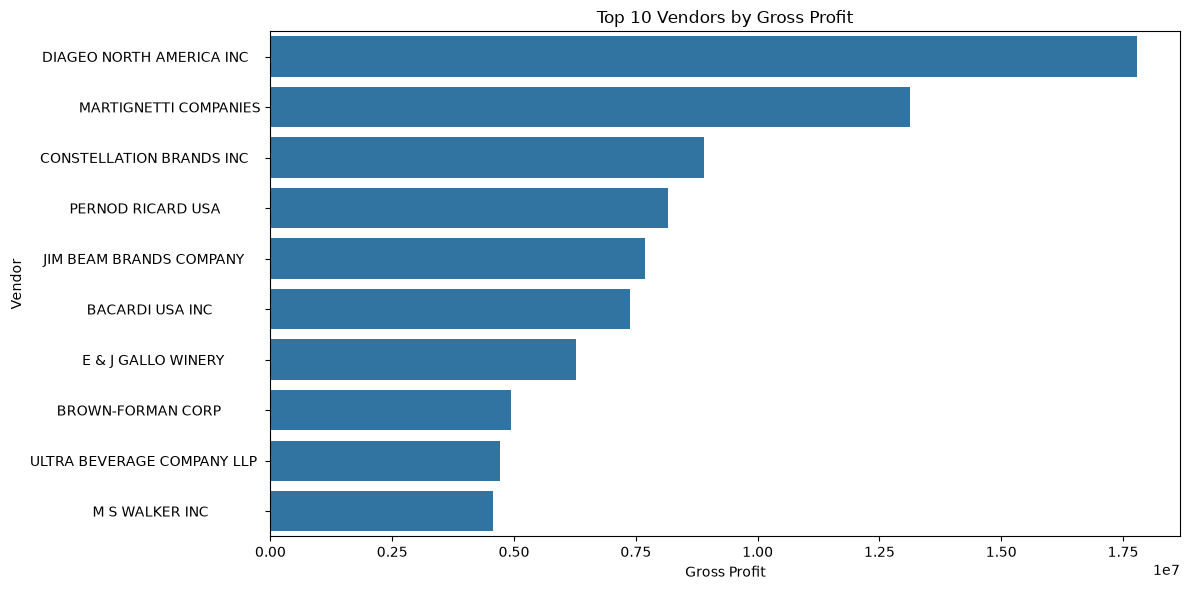

In [14]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_vendors_profit,
    x="gross_profit",
    y="VendorName"
)

plt.title("Top 10 Vendors by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

In [15]:
low_margin_products = (
    df[df["profit_margin_percent"] < 10]
    .sort_values("profit_margin_percent")
    .head(20)
)

low_margin_products[
    [
        "VendorName",
        "Brand",
        "Description",
        "total_sales_dollars",
        "gross_profit",
        "profit_margin_percent",
        "unsold_quantity"
    ]
]

,VendorName,Brand,Description,total_sales_dollars,gross_profit,profit_margin_percent,unsold_quantity
8399,TREASURY WINE ESTATES,27342,19 Crimes The Banished Red,38.97,-9247.83,-23730.64,1062
1558,SOUTHERN WINE & SPIRITS NE,15880,San Polo Brun di Montlcno 11,149.98,-29064.02,-19378.60,598
4075,MARTIGNETTI COMPANIES,27553,Hedges Family Estate Red Mtn,26.99,-4022.29,-14902.89,227
7055,ULTRA BEVERAGE COMPANY LLP,27274,Jos Phelps Insignia 13,209.99,-23671.51,-11272.68,173
1502,SOUTHERN GLAZERS W&S OF NE,27969,Fattoria le Pupille Poggio,36.99,-4052.13,-10954.66,167
10200,VINILANDIA USA,22591,Ch Manos Cadillac,15.99,-1519.93,-9505.50,145
7224,M S WALKER INC,2094,Kilchoman Machir Bay Whiskey,133.98,-11015.22,-8221.54,226
3272,MARTIGNETTI COMPANIES,13557,Merry Edwards Flax Vyd Pnt N,69.99,-5456.01,-7795.41,119
3358,MARTIGNETTI COMPANIES,15901,Merry Edwards Georg Pnt Nr,79.99,-5880.41,-7351.43,119
1743,SOUTHERN WINE & SPIRITS NE,26266,The Divining Rod Pinot Noir,33.98,-1491.94,-4390.64,130


In [16]:
high_unsold_products = (
    df.sort_values("unsold_quantity", ascending=False)
      .head(20)
)

high_unsold_products[
    [
        "VendorName",
        "Brand",
        "Description",
        "total_purchase_quantity",
        "total_sales_quantity",
        "unsold_quantity",
        "gross_profit",
        "profit_margin_percent"
    ]
]

,VendorName,Brand,Description,total_purchase_quantity,total_sales_quantity,unsold_quantity,gross_profit,profit_margin_percent
2830,DIAGEO NORTH AMERICA INC,3102,Smirnoff Traveler,161386,148265,13121,503706.51,19.43
9557,JIM BEAM BRANDS COMPANY,3581,Pinnacle Citrus,19681,9188,10493,-5467.82,-60.11
9558,JIM BEAM BRANDS COMPANY,3594,Pinnacle Tropical Punch,21089,11443,9646,-4909.96,-43.34
9554,JIM BEAM BRANDS COMPANY,3566,Pinnacle Raspberry,20642,11128,9514,-3639.10,-33.03
9561,JIM BEAM BRANDS COMPANY,3638,Pinnacle Whipped,23765,14844,8921,-3128.19,-21.29
9548,JIM BEAM BRANDS COMPANY,3454,Pinnacle Pineapple,20816,11940,8876,-3166.92,-26.79
5936,LUXCO INC,2107,Rebel Yell Ginger Bourbon,18158,11208,6950,-2341.00,-21.10
7296,M S WALKER INC,5609,Integre Vodka,7171,430,6741,-30984.58,-1202.96
649,BROWN-FORMAN CORP,1771,Jack Daniels Tennessee Fire,30000,23639,6361,48180.61,68.17
6022,"STOLI GROUP,(USA) LLC",7956,Bayou Satsuma Rum Liqueur,16973,10626,6347,-2888.93,-27.46


In [17]:
meaningful_low_margin_products = (
    df[
        (df["total_sales_dollars"] >= 1000) &
        (df["profit_margin_percent"] < 10)
    ]
    .sort_values("profit_margin_percent")
    .head(20)
)

meaningful_low_margin_products[
    [
        "VendorName",
        "Brand",
        "Description",
        "total_sales_dollars",
        "total_purchase_dollars",
        "gross_profit",
        "profit_margin_percent",
        "unsold_quantity"
    ]
]

,VendorName,Brand,Description,total_sales_dollars,total_purchase_dollars,gross_profit,profit_margin_percent,unsold_quantity
4100,MARTIGNETTI COMPANIES,27872,Flora Springs Napa Red,1403.48,24339.84,-22936.36,-1634.25,1292
9068,PERFECTA WINES,27290,Ch Pape Clement Pess-Leo 13,1039.92,14367.36,-13327.44,-1281.58,160
7296,M S WALKER INC,5609,Integre Vodka,2575.70,33560.28,-30984.58,-1202.96,6741
4106,MARTIGNETTI COMPANIES,27886,Roth Estate Pinot Noir,1154.23,14244.96,-13090.73,-1134.15,1339
8503,PERFECTA WINES,2807,Couvreur Pale Single Malt,2069.77,24919.20,-22849.43,-1103.96,337
7239,M S WALKER INC,2764,Hatfield & McCoy Whiskey,1195.61,14394.00,-13198.39,-1103.90,561
651,BROWN-FORMAN CORP,1801,Jack Daniels Tennesse Fire,1350.96,14535.82,-13184.86,-975.96,1407
9476,JIM BEAM BRANDS COMPANY,2204,Bowmore 25 Yr Single Malt,2579.94,27073.35,-24493.41,-949.38,79
8504,PERFECTA WINES,2817,Couvreur Overaged 12 Yr Malt,2029.71,19533.60,-17503.89,-862.38,331
9461,JIM BEAM BRANDS COMPANY,1994,Laphroaig 30 Year,1999.98,18604.56,-16604.58,-830.24,22


In [18]:
high_unsold_products = (
    df[
        df["total_purchase_quantity"] >= 100
    ]
    .sort_values("unsold_quantity", ascending=False)
    .head(20)
)

high_unsold_products[
    [
        "VendorName",
        "Brand",
        "Description",
        "total_purchase_quantity",
        "total_sales_quantity",
        "unsold_quantity",
        "total_sales_dollars",
        "gross_profit",
        "profit_margin_percent"
    ]
]

,VendorName,Brand,Description,total_purchase_quantity,total_sales_quantity,unsold_quantity,total_sales_dollars,gross_profit,profit_margin_percent
2830,DIAGEO NORTH AMERICA INC,3102,Smirnoff Traveler,161386,148265,13121,2592041.35,503706.51,19.43
9557,JIM BEAM BRANDS COMPANY,3581,Pinnacle Citrus,19681,9188,10493,9096.12,-5467.82,-60.11
9558,JIM BEAM BRANDS COMPANY,3594,Pinnacle Tropical Punch,21089,11443,9646,11328.57,-4909.96,-43.34
9554,JIM BEAM BRANDS COMPANY,3566,Pinnacle Raspberry,20642,11128,9514,11016.72,-3639.10,-33.03
9561,JIM BEAM BRANDS COMPANY,3638,Pinnacle Whipped,23765,14844,8921,14695.56,-3128.19,-21.29
9548,JIM BEAM BRANDS COMPANY,3454,Pinnacle Pineapple,20816,11940,8876,11820.60,-3166.92,-26.79
5936,LUXCO INC,2107,Rebel Yell Ginger Bourbon,18158,11208,6950,11095.92,-2341.00,-21.10
7296,M S WALKER INC,5609,Integre Vodka,7171,430,6741,2575.70,-30984.58,-1202.96
649,BROWN-FORMAN CORP,1771,Jack Daniels Tennessee Fire,30000,23639,6361,70680.61,48180.61,68.17
6022,"STOLI GROUP,(USA) LLC",7956,Bayou Satsuma Rum Liqueur,16973,10626,6347,10519.74,-2888.93,-27.46


In [19]:
vendor_contribution = (
    df.groupby("VendorName", as_index=False)
      .agg(total_sales_dollars=("total_sales_dollars", "sum"))
)

total_sales = vendor_contribution["total_sales_dollars"].sum()

vendor_contribution["sales_contribution_percent"] = (
    vendor_contribution["total_sales_dollars"] / total_sales * 100
)

vendor_contribution = vendor_contribution.sort_values(
    "sales_contribution_percent", 
    ascending=False
)

vendor_contribution.head(10)

,VendorName,total_sales_dollars,sales_contribution_percent
27,DIAGEO NORTH AMERICA INC,68739834.97,15.217408
61,MARTIGNETTI COMPANIES,40905207.45,9.055466
73,PERNOD RICARD USA,32279544.17,7.145944
49,JIM BEAM BRANDS COMPANY,31898621.16,7.061616
7,BACARDI USA INC,25005365.79,5.535609
22,CONSTELLATION BRANDS INC,24467134.23,5.416457
32,E & J GALLO WINERY,18553774.66,4.107376
13,BROWN-FORMAN CORP,18476611.60,4.090294
113,ULTRA BEVERAGE COMPANY LLP,17802646.10,3.941094
57,M S WALKER INC,15436066.26,3.417188


In [20]:
vendor_contribution["cumulative_contribution_percent"] = (
    vendor_contribution["sales_contribution_percent"].cumsum()
)

vendor_contribution.head(20)

,VendorName,total_sales_dollars,sales_contribution_percent,cumulative_contribution_percent
27,DIAGEO NORTH AMERICA INC,68739834.97,15.217408,15.217408
61,MARTIGNETTI COMPANIES,40905207.45,9.055466,24.272873
73,PERNOD RICARD USA,32279544.17,7.145944,31.418817
49,JIM BEAM BRANDS COMPANY,31898621.16,7.061616,38.480433
7,BACARDI USA INC,25005365.79,5.535609,44.016042
22,CONSTELLATION BRANDS INC,24467134.23,5.416457,49.432499
32,E & J GALLO WINERY,18553774.66,4.107376,53.539875
13,BROWN-FORMAN CORP,18476611.60,4.090294,57.630169
113,ULTRA BEVERAGE COMPANY LLP,17802646.10,3.941094,61.571263
57,M S WALKER INC,15436066.26,3.417188,64.988450


In [21]:
vendor_profitability = (
    df.groupby("VendorName", as_index=False)
      .agg(
          total_sales_dollars=("total_sales_dollars", "sum"),
          total_purchase_dollars=("total_purchase_dollars", "sum"),
          gross_profit=("gross_profit", "sum"),
          total_sales_quantity=("total_sales_quantity", "sum"),
          total_purchase_quantity=("total_purchase_quantity", "sum")
      )
)

vendor_profitability["profit_margin_percent"] = (
    vendor_profitability["gross_profit"] / vendor_profitability["total_sales_dollars"] * 100
)

vendor_profitability = vendor_profitability.sort_values(
    "profit_margin_percent", 
    ascending=False
)

vendor_profitability.head(10)

,VendorName,total_sales_dollars,total_purchase_dollars,gross_profit,total_sales_quantity,total_purchase_quantity,profit_margin_percent
37,FLAVOR ESSENCE INC,1474.41,17.00,1457.41,59,1,98.846996
18,CAPSTONE INTERNATIONAL,246.87,54.64,192.23,13,4,77.866894
90,SILVER MOUNTAIN CIDERS,342.51,77.18,265.33,49,17,77.466351
1,ALISA CARR BEVERAGES,113590.18,34951.68,78638.50,982,438,69.230016
94,STAR INDUSTRIES INC.,7870.76,2452.29,5418.47,424,151,68.843034
108,THE PIERPONT GROUP LLC,17531.50,5713.19,11818.31,1050,580,67.411859
81,R.P.IMPORTS INC,50845.60,18623.87,32221.73,940,486,63.371718
35,FANTASY FINE WINES CORP,327.59,128.64,198.95,41,24,60.731402
115,VINEDREA WINES LLC,11385.60,4657.60,6728.00,440,205,59.092187
10,BLACK PRINCE DISTILLERY INC,11697.04,5971.94,5725.10,1096,807,48.944861


In [22]:
low_performing_vendors = (
    vendor_profitability[
        (vendor_profitability["total_sales_dollars"] >= 100000) &
        (vendor_profitability["profit_margin_percent"] < 15)
    ]
    .sort_values("profit_margin_percent")
)

low_performing_vendors

,VendorName,total_sales_dollars,total_purchase_dollars,gross_profit,total_sales_quantity,total_purchase_quantity,profit_margin_percent
83,Russian Standard Vodka,139135.55,138907.27,228.28,15195,12798,0.164070
14,BULLY BOY DISTILLERS,119484.53,117928.22,1556.31,4447,5382,1.302520
68,NICHE W & S,114938.96,111031.77,3907.19,10404,9277,3.399361
53,LAIRD & CO,213108.09,203011.58,10096.51,20141,21422,4.737741
15,CALEDONIA SPIRITS INC,278648.38,259604.70,19043.68,7162,8202,6.834305
30,DUGGANS DISTILLED PRODUCTS,202338.62,184296.50,18042.12,15738,18814,8.916795
34,FABRIZIA SPIRITS LLC,396503.92,358390.62,38113.30,25508,28071,9.612339
87,SEA HAGG DISTILLERY LLC,213002.55,188044.46,24958.09,13145,15412,11.717273
60,MARSALLE COMPANY,215253.60,185311.19,29942.41,6640,7158,13.910295


In [23]:
high_unsold_products = (
    df[
        (df["total_purchase_quantity"] >= 100) &
        (df["unsold_quantity"] > 0)
    ]
    .sort_values("unsold_quantity", ascending=False)
    .head(20)
)

high_unsold_products[
    [
        "VendorName",
        "Brand",
        "Description",
        "total_purchase_quantity",
        "total_sales_quantity",
        "unsold_quantity",
        "sales_to_purchase_qty_ratio",
        "gross_profit",
        "profit_margin_percent"
    ]
]

,VendorName,Brand,Description,total_purchase_quantity,total_sales_quantity,unsold_quantity,sales_to_purchase_qty_ratio,gross_profit,profit_margin_percent
2830,DIAGEO NORTH AMERICA INC,3102,Smirnoff Traveler,161386,148265,13121,0.92,503706.51,19.43
9557,JIM BEAM BRANDS COMPANY,3581,Pinnacle Citrus,19681,9188,10493,0.47,-5467.82,-60.11
9558,JIM BEAM BRANDS COMPANY,3594,Pinnacle Tropical Punch,21089,11443,9646,0.54,-4909.96,-43.34
9554,JIM BEAM BRANDS COMPANY,3566,Pinnacle Raspberry,20642,11128,9514,0.54,-3639.10,-33.03
9561,JIM BEAM BRANDS COMPANY,3638,Pinnacle Whipped,23765,14844,8921,0.62,-3128.19,-21.29
9548,JIM BEAM BRANDS COMPANY,3454,Pinnacle Pineapple,20816,11940,8876,0.57,-3166.92,-26.79
5936,LUXCO INC,2107,Rebel Yell Ginger Bourbon,18158,11208,6950,0.62,-2341.00,-21.10
7296,M S WALKER INC,5609,Integre Vodka,7171,430,6741,0.06,-30984.58,-1202.96
649,BROWN-FORMAN CORP,1771,Jack Daniels Tennessee Fire,30000,23639,6361,0.79,48180.61,68.17
6022,"STOLI GROUP,(USA) LLC",7956,Bayou Satsuma Rum Liqueur,16973,10626,6347,0.63,-2888.93,-27.46


In [24]:
meaningful_low_margin_products = (
    df[
        (df["total_sales_dollars"] >= 10000) &
        (df["profit_margin_percent"] < 10)
    ]
    .sort_values("profit_margin_percent")
    .head(20)
)

meaningful_low_margin_products[
    [
        "VendorName",
        "Brand",
        "Description",
        "total_sales_dollars",
        "total_purchase_dollars",
        "gross_profit",
        "profit_margin_percent",
        "unsold_quantity"
    ]
]

,VendorName,Brand,Description,total_sales_dollars,total_purchase_dollars,gross_profit,profit_margin_percent,unsold_quantity
8498,PERFECTA WINES,2289,Whistle Pig Boss Hog Rye,11062.63,44489.34,-33426.71,-302.16,149
9480,JIM BEAM BRANDS COMPANY,2277,Kilbeggan Irish Whiskey,20272.54,72275.32,-52002.78,-256.52,2698
8479,Russian Standard Vodka,3365,Russian Standard Vodka,12569.97,41850.60,-29280.63,-232.94,1741
5429,REMY COINTREAU USA INC,4785,Remy Martin XO Excellence,21237.26,59398.95,-38161.69,-179.69,827
5990,"STOLI GROUP,(USA) LLC",749,Stolichnaya Hot Vodka,16683.75,38213.36,-21529.61,-129.05,899
9505,JIM BEAM BRANDS COMPANY,2842,Laphroaig 25 Yr Cask Strenth,12999.71,29472.52,-16472.81,-126.72,69
7205,M S WALKER INC,814,Sammy's Beach Bar Rum,10306.06,21786.46,-11480.40,-111.39,520
3989,MARTIGNETTI COMPANIES,26708,Monte del Fra Amarone Valpol,14082.90,28505.52,-14422.62,-102.41,376
4052,MARTIGNETTI COMPANIES,27255,D'Arry's Original Shrz/Grnch,11488.40,22426.60,-10938.20,-95.21,900
2004,E & J GALLO WINERY,3283,New Amsterdam Apple Vodka,19321.69,37611.80,-18290.11,-94.66,1489


In [25]:
df["purchase_volume_group"] = pd.qcut(
    df["total_purchase_quantity"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

bulk_purchase_impact = (
    df.groupby("purchase_volume_group", observed=True)
      .agg(
          product_count=("Brand", "count"),
          avg_purchase_price=("avg_purchase_price", "mean"),
          avg_sales_price=("avg_sales_price", "mean"),
          avg_profit_margin=("profit_margin_percent", "mean"),
          avg_sales_to_purchase_ratio=("sales_to_purchase_qty_ratio", "mean")
      )
      .reset_index()
)

bulk_purchase_impact

,purchase_volume_group,product_count,avg_purchase_price,avg_sales_price,avg_profit_margin,avg_sales_to_purchase_ratio
0,Low,2754,47.025258,67.695933,-18.403101,3.588678
1,Medium,2504,19.139217,28.029165,-66.976450,1.304225
2,High,2628,15.751731,22.599707,-7.219380,0.966240
3,Very High,2629,10.383560,15.127531,26.795759,0.974553


In [26]:
correlation_columns = [
    "total_purchase_quantity",
    "total_purchase_dollars",
    "total_sales_quantity",
    "total_sales_dollars",
    "gross_profit",
    "profit_margin_percent",
    "unsold_quantity",
    "sales_to_purchase_qty_ratio"
]

df[correlation_columns].corr()

,total_purchase_quantity,total_purchase_dollars,total_sales_quantity,total_sales_dollars,gross_profit,profit_margin_percent,unsold_quantity,sales_to_purchase_qty_ratio
total_purchase_quantity,1.000000,0.675643,0.998671,0.687651,0.695215,0.025989,0.267919,-0.035568
total_purchase_dollars,0.675643,1.000000,0.673755,0.996390,0.951405,0.019043,0.199537,-0.030976
total_sales_quantity,0.998671,0.673755,1.000000,0.687218,0.698673,0.028727,0.217906,-0.030756
total_sales_dollars,0.687651,0.996390,0.687218,1.000000,0.974113,0.025397,0.175254,-0.028727
gross_profit,0.695215,0.951405,0.698673,0.974113,1.000000,0.041416,0.104368,-0.021718
profit_margin_percent,0.025989,0.019043,0.028727,0.025397,0.041416,1.000000,-0.044850,0.048965
unsold_quantity,0.267919,0.199537,0.217906,0.175254,0.104368,-0.044850,1.000000,-0.098602
sales_to_purchase_qty_ratio,-0.035568,-0.030976,-0.030756,-0.028727,-0.021718,0.048965,-0.098602,1.000000


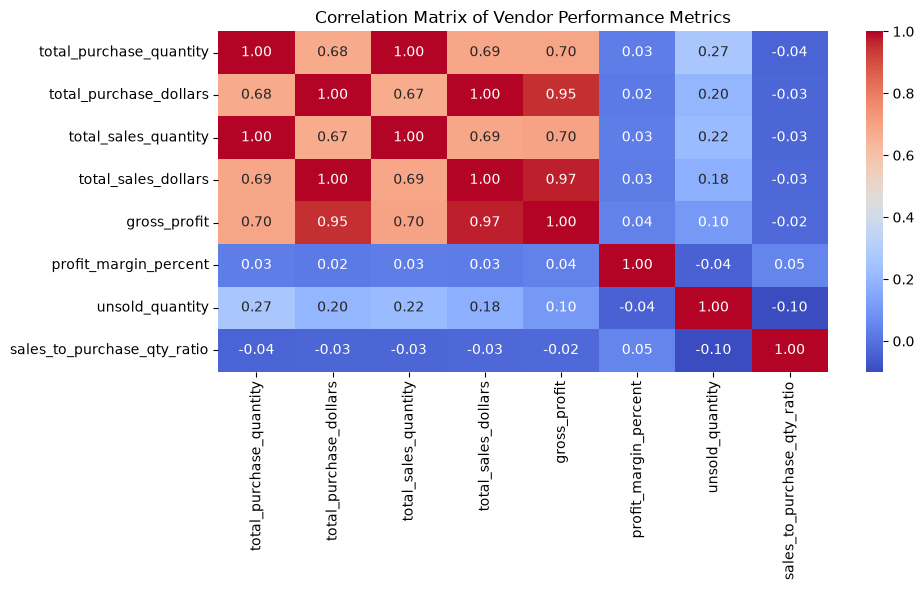

In [27]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Vendor Performance Metrics")
plt.tight_layout()
plt.show()

In [28]:
vendor_stats = (
    df.groupby("VendorName", as_index=False)
      .agg(
          total_sales_dollars=("total_sales_dollars", "sum"),
          gross_profit=("gross_profit", "sum")
      )
)

vendor_stats["profit_margin_percent"] = (
    vendor_stats["gross_profit"] / vendor_stats["total_sales_dollars"] * 100
)

high_sales_threshold = vendor_stats["total_sales_dollars"].quantile(0.75)
low_sales_threshold = vendor_stats["total_sales_dollars"].quantile(0.25)

high_performing_vendors = vendor_stats[
    vendor_stats["total_sales_dollars"] >= high_sales_threshold
]

low_performing_vendors_stat = vendor_stats[
    vendor_stats["total_sales_dollars"] <= low_sales_threshold
]

high_performing_vendors["profit_margin_percent"].describe(), low_performing_vendors_stat["profit_margin_percent"].describe()

(count    32.000000
 mean     29.955080
 std       5.035394
 min      21.520432
 25%      26.200064
 50%      29.124832
 75%      34.857428
 max      38.434672
 Name: profit_margin_percent, dtype: float64,
 count      32.000000
 mean      -51.586288
 std       275.977935
 min     -1478.652435
 25%       -42.501635
 50%        24.139344
 75%        45.069349
 max        98.846996
 Name: profit_margin_percent, dtype: float64)